# Extração de dados do TRT4 

adicional noturno 
intervalo intrajornada 
duração de jornada 
regime 12 x 36 
13765	Adicional Noturno
		13777	Prorrogação do Horário Noturno
13771	Intervalo Interjornadas
		13772	Intervalo Intrajornada
		13799	Adicional de Hora Extra
		13800	Intervalo 15 Minutos Mulher
        13802	Natureza Jurídica da Parcela/Repercussão
		13803	Redução/Supressão
13784	Regime 12x36
13523	Regime 12 x 36



Objetivo: Extrair dados do Datajud de 2024 e 2025 (data ajuizamento) com assuntos sobre jornada

Altere a query de acordo com o que deseja buscar. Use os padrões encontrados na Tabela Processual Unificada do CNJ https://www.cnj.jus.br/sgt/consulta_publica_classes.php e siga o padrão Elastic Search

## Importações e Funções

In [1]:
!pip install pandas matplotlib requests json re csv matplotlib-venn
!pip install matplotlib
!pip install seaborn
!pip install plotly seaborn 
!pip install "nbformat>=4.2.0"

ERROR: Could not find a version that satisfies the requirement json (from versions: none)
ERROR: No matching distribution found for json


In [2]:
import time
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import pandas as pd
import matplotlib.pyplot as plt
import requests
import json
import re
import csv


def formatar_cnj(numero):
    # Remove quaisquer caracteres não numéricos
    num = re.sub(r'\D', '', str(numero))

    # Se o número tiver mais de 20 dígitos, remove o último dígito até ficar com 20
    while len(num) > 20:
        num = num[:-1]

    # Se não tiver exatamente 20 dígitos após o ajuste, retorne como está ou levante erro
    if len(num) != 20:
        return numero

    # Formatar: 0000000-00.0000.0.00.0000
    return f"{num[:7]}-{num[7:9]}.{num[9:13]}.{num[13]}.{num[14:16]}.{num[16:20]}"
    
def _criar_sessao_robusta():
    """Cria uma sessão requests com retry automático para status 5xx e 429."""
    session = requests.Session()
    retry = Retry(
        total=5,
        backoff_factor=1,
        status_forcelist=[500, 502, 503, 504, 408, 429]
    )
    adapter = HTTPAdapter(max_retries=retry)
    session.mount('http://', adapter)
    session.mount('https://', adapter)
    return session

def _fazer_requisicao_com_retry(url, headers, payload, tribunal_sigla, max_tentativas=5, timeout_base=30):
    """
    Faz requisição POST com retry automático e backoff exponencial.
    Retorna (response, sucesso) onde sucesso é True se status == 200.
    """
    for tentativa in range(max_tentativas):
        try:
            print(f"  [{tribunal_sigla}] Tentativa {tentativa + 1}/{max_tentativas}...", end=" ")
            response = requests.post(
                url, 
                headers=headers, 
                data=json.dumps(payload), 
                timeout=timeout_base
            )
            
            if response.status_code == 200:
                print("✓ 200 OK")
                return response, True
            elif response.status_code in [503, 504, 408, 429]:
                aguarda = 2 ** tentativa
                print(f"✗ {response.status_code}. Aguardando {aguarda}s...")
                time.sleep(aguarda)
            else:
                print(f"✗ {response.status_code}")
                return response, False
                
        except requests.Timeout:
            aguarda = 2 ** tentativa
            print(f"✗ Timeout. Aguardando {aguarda}s...")
            time.sleep(aguarda)
        except requests.RequestException as e:
            aguarda = 2 ** tentativa
            print(f"✗ Erro: {str(e)[:50]}. Aguardando {aguarda}s...")
            time.sleep(aguarda)
    
    print(f"✗ Falha após {max_tentativas} tentativas")
    return None, False

def busca_datajud_api(payload_template, tribunais):
    """
    Consulta a API pública do DataJud para uma lista de tribunais e retorna um DataFrame
    com os processos encontrados.

    Correções e melhorias:
    - Evita sobrescrever a variável 'tribunal' usada no loop (usa 'tribunal_slug' / 'sigla').
    - Trata respostas não-JSON / corpo vazio / status diferente de 200 para evitar JSONDecodeError.
    - Protege acessos a chaves no dicionário com .get() para evitar KeyError.
    - Logs informativos quando a API não retorna o esperado.
    """

    processos = []  # lista de resultados agregados

    for tribunal_slug in tribunais:
        total_resultados_tribunal = 0

        url = f"https://api-publica.datajud.cnj.jus.br/{tribunal_slug}/_search"
        sigla = tribunal_slug.split('_')[-1].upper()

        payload = payload_template.copy()  # copia o payload para cada tribunal
        search_after = None

        while True:
            # Atualiza o search_after se for necessário
            if search_after is not None:
                payload["search_after"] = [search_after]
            else:
                payload.pop("search_after", None)  # remove se não for necessário

            # Faz a requisição com tratamento de erros de conexão
            
            # Requisição com retry automático
            response, sucesso = _fazer_requisicao_com_retry(
                url, headers, payload, sigla, max_tentativas=5, timeout_base=300
            )
            
            if not sucesso or response is None:
                break

            # Verifica corpo vazio
            if not response.text or response.text.strip() == "":
                print(f"API do {sigla} retornou corpo vazio")
                break

            # Tenta decodificar JSON com tratamento de erro
            try:
                dados_dict = response.json()
            except ValueError:
                preview = response.text[:200].replace("\n", " ")
                print(f"Resposta da API do {sigla} não é JSON válido. Preview: {preview}")
                break

            # Extrai os hits com segurança
            hits = dados_dict.get('hits')
            if not hits or 'hits' not in hits:
                print(f'A API do {sigla} não retornou resultados')
                break

            resultados = hits.get('hits', [])
            total = hits.get('total', {}).get('value', 0)
            total_resultados_tribunal += len(resultados)

            for processo in resultados:
                src = processo.get('_source', {})

                classe = src.get('classe', {}) or {}
                classe_codigo = classe.get('codigo')
                classe_nome = classe.get('nome')

                numero_processo = str(src.get('numeroProcesso', '') or '')

                sistema = (src.get('sistema') or {}).get('nome')
                formato = (src.get('formato') or {}).get('nome')

                # orgaoJulgador pode ser dict ou string; tratamos ambos
                orgao = src.get('orgaoJulgador')
                if isinstance(orgao, dict):
                    codigo_orgao_julgador = orgao.get('codigo')
                    orgao_julgador = orgao.get('nome') or orgao
                    codigo_municipio = orgao.get('codigoMunicipioIBGE')
                else:
                    codigo_orgao_julgador = orgao
                    orgao_julgador = orgao
                    codigo_municipio = None

                grau = src.get('grau')
                nivel_sigilo = src.get('nivelSigilo')
                assuntos = src.get('assuntos')
                data_ajuizamento = src.get('dataAjuizamento')
                ultima_atualizacao = src.get('dataHoraUltimaAtualizacao')

                movimentos = src.get('movimentos', [])

                # Guardamos a sigla do tribunal para não correr risco de sobrescrever
                processos.append([
                    sigla, orgao_julgador, codigo_municipio, grau, nivel_sigilo,
                    numero_processo, sistema, formato, classe_nome, classe_codigo,
                    json.dumps(assuntos, ensure_ascii=False), data_ajuizamento, ultima_atualizacao, json.dumps(movimentos, ensure_ascii=False)
                ])

            # Atualiza search_after usando o último sort retornado (se existir)
            if resultados:
                last_sort = resultados[-1].get('sort', [])
                search_after = last_sort[0] if last_sort else None

            # Se o número de resultados retornados for menor que a página (ou que 10000),
            # consideramos que não há mais resultados a paginar.
            if len(resultados) < 10000:
                break
            # Sleep entre paginações para não sobrecarregar
            time.sleep(2)

        print(f'A API do {sigla} retornou {total_resultados_tribunal} resultados')

    # Cria DataFrame
    if processos:
        df = pd.DataFrame(processos, columns=[
            'tribunal', 'orgao_julgador', 'codigo_municipio', 'grau', 'nivel_sigilo',
            'numero_processo', 'sistema', 'formato', 'classe_nome', 'classe_codigo',
            'assuntos', 'data_ajuizamento', 'ultima_atualizacao', 'movimentos'
        ])
        df = df.drop_duplicates(subset=['numero_processo'], keep='first')
        df = df.reset_index(drop=True)
    else:
        # DataFrame vazio com colunas esperadas
        df = pd.DataFrame(columns=[
            'tribunal', 'orgao_julgador', 'codigo_municipio', 'grau', 'nivel_sigilo',
            'numero_processo', 'sistema', 'formato', 'classe_nome', 'classe_codigo',
            'assuntos', 'data_ajuizamento', 'ultima_atualizacao', 'movimentos'
        ])

    print(f'DF criado com {df.shape[0]} linhas')
    return df

## Variáveis de Configuração

In [3]:
#Variáveis de conexão com o Datajud
api_key = "APIKey cDZHYzlZa0JadVREZDJCendQbXY6SkJlTzNjLV9TRENyQk1RdnFKZGRQdw==" # Chave pública

headers = {
  'Authorization': api_key,
  'Content-Type': 'application/json'
}

tribunais = [
    "api_publica_trt4",
]
#sigla_estado = 'stj'  # sigla do estado para nomear os arquivos

## Extração de Dados - Plano de saúde

In [4]:
payload_template = {
  "size": 10000,
  "query": {
      "bool": {
         "should": [
          {"match": {"assuntos.codigo": 13765}},  # Adicional Noturno
          {"match": {"assuntos.codigo": 13777}},  # Prorrogação do Horário Noturno
          {"match": {"assuntos.codigo": 13771}},   # Intervalo Interjornadas
          {"match": {"assuntos.codigo": 13772}},   # Intervalo Intrajornada
          {"match": {"assuntos.codigo": 13799}},  # Adicional de Hora Extra
          {"match": {"assuntos.codigo": 13802}},  # Natureza Jurídica da Parcela/Repercussão
          {"match": {"assuntos.codigo": 13803}},  # Redução/Supressão
          {"match": {"assuntos.codigo": 13784}},  # Regime 12x36
          {"match": {"assuntos.codigo": 13523}},  # Regime 12 x 36 (crossed out)
      ],
      "minimum_should_match": 1
      }
  },
  "sort": [{"@timestamp": {"order": "asc"}}]
}

In [5]:
df = busca_datajud_api(payload_template, tribunais)

  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1/5... ✓ 200 OK
  [TRT4] Tentativa 1

In [6]:
df.to_csv(f'data/raw/dftrt4_jornada_trabalho.csv', quoting=csv.QUOTE_ALL)
df.to_parquet(f'data/raw/dftrt4_jornada_trabalho.parquet')

## Limpeza


### Importação

In [ ]:
import pandas as pd 
df = pd.read_csv(f'df_stj_resp.csv')

### Formatação Número CNJ 

In [7]:
#Formatação dos número do processo no estilo CNJ
df['numero_processo_cnj'] = df['numero_processo'].apply(formatar_cnj)

#Todos os DataFrames estão com a coluna como string
df['numero_processo_cnj'] = df['numero_processo_cnj'].astype(str)

## Recorte temporal

In [ ]:
# Converter data_ajuizamento para datetime (com tratamento de múltiplos formatos)
def converter_data_flexivel(x):
    if pd.isna(x):
        return pd.NaT
    s = str(x).strip()
    if not s:
        return pd.NaT
    
    dt = None
    
    # Formato ISO com timezone: 2321-10-07T00:00:00.000Z
    if 'T' in s:
        try:
            dt = pd.to_datetime(s)
        except:
            pass
    
    # Se for número puro (timestamp formato YYYYMMDDHHMMSS)
    if dt is None and s.isdigit():
        if len(s) == 14:  # formato 20230112000000
            try:
                dt = pd.to_datetime(s, format='%Y%m%d%H%M%S')
            except:
                pass
        elif len(s) >= 10:  # timestamp em segundos
            try:
                dt = pd.to_datetime(int(s), unit='s')
            except:
                pass
    
    # Caso contrário, tentar parse padrão
    if dt is None:
        try:
            dt = pd.to_datetime(s)
        except:
            return pd.NaT
    
    # REMOVER TIMEZONE se houver (normalize para tz-naive)
    if dt is pd.NaT:
        return pd.NaT
    if hasattr(dt, 'tz') and dt.tz is not None:
        dt = dt.tz_localize(None)
    
    return dt

# Aplicar conversão
df['data_ajuizamento'] = df['data_ajuizamento'].apply(converter_data_flexivel)

# Agora é seguro fazer astype (tudo é tz-naive)
df['data_ajuizamento'] = pd.to_datetime(df['data_ajuizamento'], errors='coerce')

print("=== DIAGNÓSTICO DE CONVERSÃO ===")
print(f"df: {df['data_ajuizamento'].notna().sum()} datas válidas de {len(df)}")


=== DIAGNÓSTICO DE CONVERSÃO ===
df: 306697 datas válidas de 306700

df: 306700 processos antes do recorte temporal


In [14]:
print(f"\ndf: {len(df)} processos antes do recorte temporal")

# Filtrar para apenas processos após 2020-01-01
data_corte_inf = pd.to_datetime('2023-01-01')
data_corte_sup = pd.to_datetime('2025-12-31')

df = df[(df['data_ajuizamento'] >= data_corte_inf) & (df['data_ajuizamento'] <= data_corte_sup)].reset_index(drop=True)

print(f"\ndf: {len(df)} processos após 2023 e de 2025")


df: 306700 processos antes do recorte temporal

df: 91218 processos após 2023 e de 2025


In [ ]:
df.to_csv(f'data/interim/dftrt4_recorte_temporal.csv', quoting=csv.QUOTE_ALL)
df.to_parquet(f'data/interim/dftrt4_recorte_temporal.parquet')

# 1o Grau e Ação trabalhista de RO 

In [32]:
df = pd.read_parquet(f'data/interim/dftrt4_recorte_temporal.parquet')

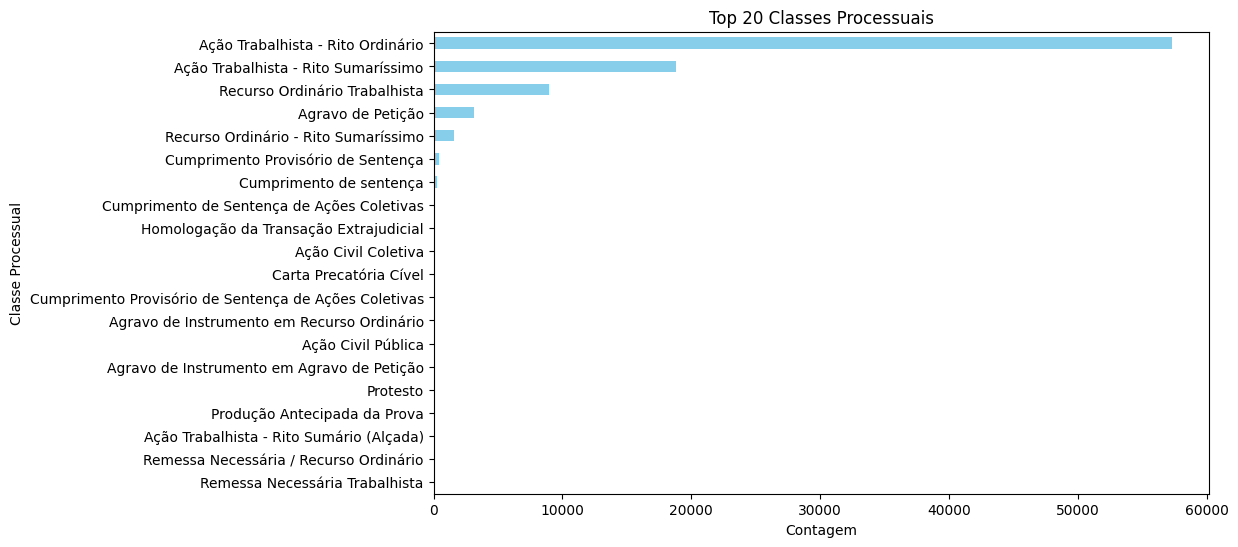

In [26]:
df['classe_nome'].value_counts().head(20).plot(kind='barh', figsize=(10,6), color='skyblue')
plt.title('Top 20 Classes Processuais')
plt.xlabel('Contagem')
plt.ylabel('Classe Processual')
plt.gca().invert_yaxis()  # Inverte o eixo y para mostrar a classe


In [33]:
df = df[df['classe_nome'] == "Ação Trabalhista - Rito Ordinário"]

In [35]:
df = df[df['grau'] == 'G1']

In [34]:
df['grau'].value_counts()

grau
G1    57266
Name: count, dtype: int64

In [37]:
df.to_parquet(f'data/interim/dftrt4_g1_ritoordinario.parquet')

In [38]:
df.head()

,tribunal,orgao_julgador,codigo_municipio,grau,nivel_sigilo,numero_processo,sistema,formato,classe_nome,classe_codigo,...,data_ajuizamento,ultima_atualizacao,movimentos,numero_processo_cnj,data_ajuizamento_orig,ano,mes,dia,dia_semana,hora
0,TRT4,4ª Gravataí,4309209,G1,0,00200517020235040234,PJe,Eletrônico,Ação Trabalhista - Rito Ordinário,985,...,2023-01-27 15:25:33,2023-02-07T16:41:53.694000Z,"[{""complementosTabelados"": [{""codigo"": 2, ""val...",0020051-70.2023.5.04.0234,2023-01-27 15:25:33,2023.0,1.0,27.0,Friday,15.0
1,TRT4,10ª Porto Alegre,4314902,G1,0,00200706920235040010,PJe,Eletrônico,Ação Trabalhista - Rito Ordinário,985,...,2023-01-30 18:27:36,2023-02-07T16:42:31.901000Z,"[{""complementosTabelados"": [{""codigo"": 2, ""val...",0020070-69.2023.5.04.0010,2023-01-30 18:27:36,2023.0,1.0,30.0,Monday,18.0
3,TRT4,2ª Pelotas,4314407,G1,0,00200491120235040102,PJe,Eletrônico,Ação Trabalhista - Rito Ordinário,985,...,2023-01-31 23:12:58,2023-02-07T17:38:11.661000Z,"[{""complementosTabelados"": [{""codigo"": 2, ""val...",0020049-11.2023.5.04.0102,2023-01-31 23:12:58,2023.0,1.0,31.0,Tuesday,23.0
4,TRT4,20ª Porto Alegre,4314902,G1,0,00200703920235040020,PJe,Eletrônico,Ação Trabalhista - Rito Ordinário,985,...,2023-01-31 18:09:13,2023-02-07T21:48:21.187000Z,"[{""complementosTabelados"": [{""codigo"": 2, ""val...",0020070-39.2023.5.04.0020,2023-01-31 18:09:13,2023.0,1.0,31.0,Tuesday,18.0
6,TRT4,27ª Porto Alegre,4314902,G1,0,00200641120235040027,PJe,Eletrônico,Ação Trabalhista - Rito Ordinário,985,...,2023-01-30 17:46:00,2023-02-08T02:11:03.638000Z,"[{""complementosTabelados"": [{""codigo"": 2, ""val...",0020064-11.2023.5.04.0027,2023-01-30 17:46:00,2023.0,1.0,30.0,Monday,17.0


# Extração de Características

In [11]:
from functools import lru_cache
import pandas as pd
import csv
import matplotlib.pyplot as plt
#import geopandas as gpd
import requests
import json
import ast
from datetime import datetime
import os
#import seaborn as sns

def encontrar_primeira_data_hora_por_codigos(movimentos, codigos_desejados):
    """
    Encontra a 'dataHora' em uma lista de movimentos para códigos específicos.
    """
    # Se for string, tenta converter para lista
    if isinstance(movimentos, str):
        try:
            movimentos = ast.literal_eval(movimentos)
        except:
            try:
                movimentos = json.loads(movimentos)
            except:
                return None

    # Se não for lista, retorna None
    if not isinstance(movimentos, list):
        return None

    # Procura pelo código desejado
    for movimento in movimentos:
        if isinstance(movimento, dict) and movimento.get('codigo') in codigos_desejados:
            return movimento.get('dataHora')

def encontrar_nome_data_hora_por_codigos(movimentos, codigos_desejados):
    """
    Encontra NOME e 'dataHora' em uma lista de movimentos para códigos específicos.
    Retorna uma tupla (dataHora, nome) ou (None, None) se não encontrado.
    """
    # Se for string, tenta converter para lista
    if isinstance(movimentos, str):
        try:
            movimentos = ast.literal_eval(movimentos)
        except:
            try:
                movimentos = json.loads(movimentos)
            except:
                return None, None

    # Se não for lista, retorna None, None
    if not isinstance(movimentos, list):
        return None, None

    # Procura pelo código desejado
    for movimento in movimentos:
        if isinstance(movimento, dict) and movimento.get('codigo') in codigos_desejados:
            return movimento.get('dataHora'), movimento.get('nome')
    
    # Se nenhum movimento foi encontrado, retorna None, None
    return None, None

def contar_tamanho_lista_datajud(lista):
    # Se for string, tenta converter para lista
    if isinstance(lista, str):
        try:
            lista = ast.literal_eval(lista)
        except:
            try:
                lista = json.loads(lista)
            except:
                return 0

    # Verifica se é uma lista válida e retorna o tamanho
    if isinstance(lista, list):
        return len(lista)

    return 0  # Se não for lista, retorna 0

def contar_ocorrencias_por_codigos(movimentos, codigos_desejados):
    if isinstance(movimentos, str):
        try:
            movimentos = ast.literal_eval(movimentos)
        except:
            try:
                movimentos = json.loads(movimentos)
            except:
                return 0

    if not isinstance(movimentos, list):
        return 0

    contador = 0
    for movimento in movimentos:
        if isinstance(movimento, dict) and movimento.get('codigo') in codigos_desejados:
            contador += 1

    return contador

def converter_data_flexivel(x):
    if pd.isna(x):
        return pd.NaT
    s = str(x).strip()
    if not s:
        return pd.NaT

    dt = None

    # Formato ISO com timezone: 2321-10-07T00:00:00.000Z
    if 'T' in s:
        try:
            dt = pd.to_datetime(s)
        except:
            pass

    # Se for número puro (timestamp formato YYYYMMDDHHMMSS)
    if dt is None and s.isdigit():
        if len(s) == 14:  # formato 20230112000000
            try:
                dt = pd.to_datetime(s, format='%Y%m%d%H%M%S')
            except:
                pass
        elif len(s) >= 10:  # timestamp em segundos
            try:
                dt = pd.to_datetime(int(s), unit='s')
            except:
                pass

    # Caso contrário, tentar parse padrão
    if dt is None:
        try:
            dt = pd.to_datetime(s)
        except:
            return pd.NaT

    # REMOVER TIMEZONE se houver (normalize para tz-naive)
    if dt is pd.NaT:
        return pd.NaT
    if hasattr(dt, 'tz') and dt.tz is not None:
        dt = dt.tz_localize(None)

    return dt


tr_to_estado = {
    '01': 'Acre',
    '02': 'Alagoas',
    '03': 'Amapá',
    '04': 'Amazonas',
    '05': 'Bahia',
    '06': 'Ceará',
    '07': 'Distrito Federal',
    '08': 'Espírito Santo',
    '09': 'Goiás',
    '10': 'Maranhão',
    '11': 'Mato Grosso',
    '12': 'Mato Grosso do Sul',
    '13': 'Minas Gerais',
    '14': 'Pará',
    '15': 'Paraíba',
    '16': 'Paraná',
    '17': 'Pernambuco',
    '18': 'Piauí',
    '19': 'Rio de Janeiro',
    '20': 'Rio Grande do Norte',
    '21': 'Rio Grande do Sul',
    '22': 'Rondônia',
    '23': 'Roraima',
    '24': 'Santa Catarina',
    '25': 'Sergipe',
    '26': 'São Paulo',
    '27': 'Tocantins'
}

def extrai_tr_numero_processo(numero_processo):
    """
    Extrai o campo TR do número do processo CNJ.
    Espera o padrão: NNNNNNN-DD.AAAA.J.TR.OOOO
    """
    try:
        partes = numero_processo.split('.')
        if len(partes) >= 4:
            tr = partes[3]
            return tr
        else:
            return None
    except Exception:
        return None

def identifica_estado(df, coluna_processo='Nº Processo'):
    """
    Adiciona uma coluna 'Estado' ao dataframe com o nome do estado referente ao campo TR.
    """
    def estado_do_processo(numero_processo):
        tr = extrai_tr_numero_processo(numero_processo)
        if tr in tr_to_estado:
            return tr_to_estado[tr]
        else:
            return 'Desconhecido'
    df['Estado'] = df[coluna_processo].apply(estado_do_processo)
    return df

    

In [ ]:
#Extrair Estado do número do processo a partir do campo TR e criar nova coluna 'Estado'
df_stj = identifica_estado(df_stj, coluna_processo='numero_processo_cnj')

In [18]:
codigos = [
    193,    # Julgamento
    385,    # Com Resolução do Mérito
    210,    # Concessão
    214,    # Concessão em Parte
    242,    # Conhecimento em Parte e Não-Provimento ou Denegação
    241,    # Conhecimento em Parte e Provimento em Parte ou Concessão em Parte
    240,    # Conhecimento em Parte e Provimento ou Concessão
    219,    # Procedência
    221,    # Procedência em Parte
    237,    # Provimento
    238,    # Provimento em Parte
    218,    # Sem Resolução de Mérito
    214,	# Concessão em Parte
    242,	# Conhecimento em Parte e Não-Provimento ou Denegação
    241,	# Conhecimento em Parte e Provimento em Parte ou Concessão em Parte
    240,	# Conhecimento em Parte e Provimento ou Concessão
    12433,	# Conjunto Agravo e Recurso Especial
    12443,	# conhecimento em parte para dar provimento ao recurso especial
    12442,	# conhecimento para conhecer em parte o recurso especial
    12439,	# conhecimento para conhecer em parte o recurso especial e dar provimento
    12440,	# conhecimento para conhecer em parte o recurso especial e negar provimento
    12441,	# Conhecimento para conhecer o recurso especial
    12438,	# conhecimento para dar parcial provimento ao recurso especial
    12434,	# Conhecimento para dar provimento ao Recurso Especial
    12437,	# Conhecimento para determinar sua autuação como Recurso Especial
    12436,	# Conhecimento para não conhecer do Recurso Especial
    12435	# Conhecimento para negar provimento ao recurso especial

]

# Aplicar função e expandir resultado em colunas
resultado = df_stj['movimentos'].apply(lambda mov: pd.Series(encontrar_nome_data_hora_por_codigos(mov, codigos)))
df_stj[['data_primeiro_julgamento', 'nome_primeiro_julgamento']] = resultado

df_stj['data_primeiro_julgamento'] = df_stj['data_primeiro_julgamento'].apply(lambda x: converter_data_flexivel(x) if x is not None else pd.NaT)
df_stj['data_primeiro_julgamento']= pd.to_datetime(df_stj['data_primeiro_julgamento'], errors='coerce')

In [19]:
df_stj.to_csv(f'df_{sigla_estado}_resp_formatado.csv', quoting=csv.QUOTE_ALL)

# EDA

In [14]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns
custom_palette = [
    "#a44a3f",  # muted red
    "#064789", # dark bright blue
    "#05668d", # dark blue
    "#427aa1", # slightly lighter blue
    "#679436", # green dark
    "#a5be00", # green light
]

df = df_stj
nome_df = 'df_STJ'
sigla_estado = 'STJ'

In [15]:
print("=" * 80)
print(f"ESTATÍSTICAS GERAIS DO DATASET - {nome_df}")
print("=" * 80)
print(f"\nDimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"\nValores Faltantes por Coluna:")
print(df.isnull().sum())
print(f"\nPercentual de Faltantes:")
print((df.isnull().sum() / len(df) * 100).round(2).astype(str) + "%")

ESTATÍSTICAS GERAIS DO DATASET - df_STJ

Dimensões do dataset: 34528 linhas x 18 colunas

Valores Faltantes por Coluna:
Unnamed: 0                      0
tribunal                        0
orgao_julgador                  0
codigo_municipio                0
grau                            0
nivel_sigilo                    0
numero_processo                 0
sistema                         0
formato                         0
classe_nome                     0
classe_codigo                   0
assuntos                        0
data_ajuizamento                0
ultima_atualizacao              0
movimentos                      0
numero_processo_cnj             0
data_primeiro_julgamento    20882
nome_primeiro_julgamento    20882
dtype: int64

Percentual de Faltantes:
Unnamed: 0                    0.0%
tribunal                      0.0%
orgao_julgador                0.0%
codigo_municipio              0.0%
grau                          0.0%
nivel_sigilo                  0.0%
numero_processo    

## EDA - Classe Processual

In [16]:
classe_nome_counts = df['classe_nome'].value_counts().head(20)

fig = px.bar(
    x=classe_nome_counts.values,
    y=classe_nome_counts.index,
    orientation='h',
    title=f'Distribuição por classe_nome - {nome_df}',
    labels={'x': 'Quantidade de Processos', 'y': 'classe_nome'},
    color=classe_nome_counts.values,
    color_continuous_scale='Teal',
    text=classe_nome_counts.values

)

fig.update_layout(
    template='plotly_white',
    height=600,
    showlegend=False,
    font=dict(size=10)
)
fig.update_traces(textposition='outside')
fig.show()

print(f"Total de classe_nomes: {df['classe_nome'].nunique()}")
print(f"\nTop classe_nomes:")
print(classe_nome_counts)

Total de classe_nomes: 1

Top classe_nomes:
classe_nome
Recurso Especial    34528
Name: count, dtype: int64


## EDA - Estados

In [15]:
estado_counts = df_stj['Estado'].value_counts()

fig = px.bar(
    x=estado_counts.values,
    y=estado_counts.index,
    orientation='h',
    title=f'Distribuição por Estado - {nome_df}',
    labels={'x': 'Quantidade de Processos', 'y': 'Estado'},
    color=estado_counts.values,
    color_continuous_scale='Teal',
    text=estado_counts.values

)

fig.update_layout(
    template='plotly_white',
    height=600,
    showlegend=False,
    font=dict(size=10)
)
fig.update_traces(textposition='outside')
fig.show()

print(f"Total de Estados: {df_stj['Estado'].nunique()}")
print(f"\nTop Estados:")
print(estado_counts)

Total de Estados: 28

Top Estados:
Estado
São Paulo              14447
Rio Grande do Sul       4333
Rio de Janeiro          2081
Paraíba                 1925
Minas Gerais            1863
Santa Catarina          1428
Distrito Federal        1371
Paraná                  1362
Bahia                    914
Mato Grosso              609
Tocantins                454
Sergipe                  452
Mato Grosso do Sul       409
Amazonas                 351
Piauí                    342
Ceará                    321
Alagoas                  310
Maranhão                 282
Rio Grande do Norte      207
Goiás                    198
Pernambuco               183
Rondônia                 149
Pará                     136
Amapá                    127
Acre                     121
Desconhecido              74
Espírito Santo            72
Roraima                    7
Name: count, dtype: int64


## EDA - Resultado Decisão

In [19]:
# prepara a Series e transforma em DataFrame para evitar ambiguidade do plotly.express
resultado_decisao_counts = df['nome_primeiro_julgamento'].fillna('Nulo').value_counts().head(20)

df_plot = resultado_decisao_counts.reset_index()
df_plot.columns = ['nome_primeiro_julgamento', 'count']

import plotly.express as px

fig = px.bar(
    df_plot,
    x='count',
    y='nome_primeiro_julgamento',
    orientation='h',
    title=f'Distribuição por nome_primeiro_julgamento - {nome_df}',
    labels={'count': 'Quantidade de Processos', 'nome_primeiro_julgamento': 'nome_primeiro_julgamento'},
    color='count',
    color_continuous_scale='Teal',
    text='count'
)

fig.update_layout(
    template='plotly_white',
    height=600,
    showlegend=False,
    font=dict(size=10)
)
fig.update_traces(textposition='outside')
fig.show()

print(f"Total de nome_primeiro_julgamento: {df['nome_primeiro_julgamento'].nunique()}")
print(f"\nTop nome_primeiro_julgamento:")
print(resultado_decisao_counts)

Total de nome_primeiro_julgamento: 17

Top nome_primeiro_julgamento:
nome_primeiro_julgamento
Nulo                                                                         20882
Provimento                                                                    5106
Provimento em Parte                                                           3376
Conhecimento em Parte e Não-Provimento ou Denegação                           2016
Conhecimento para determinar sua autuação como Recurso Especial               1189
Conhecimento em Parte e Provimento em Parte ou Concessão em Parte              926
Conhecimento em Parte e Provimento ou Concessão                                488
Conhecimento para não conhecer do Recurso Especial                             224
Conhecimento para negar provimento ao recurso especial                         112
conhecimento para conhecer em parte o recurso especial e negar provimento       92
Conhecimento para dar provimento ao Recurso Especial                        

In [31]:
# Preparar dados para gráfico empilhado por ano
df_temp = df.dropna(subset=['data_ajuizamento']).copy()
df_temp['data_ajuizamento'] = pd.to_datetime(df_temp['data_ajuizamento'], errors='coerce')
df_temp = df_temp.dropna(subset=['data_ajuizamento'])
df_temp['ano'] = df_temp['data_ajuizamento'].dt.year
df_temp['nome_primeiro_julgamento'] = df_temp['nome_primeiro_julgamento'].fillna('Nulo')

# Pegar os top 10 julgamentos para não poluir o gráfico
top_julgamentos = df_temp['nome_primeiro_julgamento'].value_counts().head(10).index.tolist()
df_temp['julgamento_agrupado'] = df_temp['nome_primeiro_julgamento'].apply(
    lambda x: x if x in top_julgamentos else 'Outros'
)

# Criar tabela de contagem por ano e julgamento
contagem_ano_julgamento = df_temp.groupby(['ano', 'julgamento_agrupado']).size().reset_index(name='count')

# Calcular total por ano para o percentual
total_por_ano = contagem_ano_julgamento.groupby('ano')['count'].sum().reset_index(name='total_ano')
contagem_ano_julgamento = contagem_ano_julgamento.merge(total_por_ano, on='ano')

# Calcular percentual
contagem_ano_julgamento['percentual'] = (contagem_ano_julgamento['count'] / contagem_ano_julgamento['total_ano'] * 100).round(1)

# Criar label customizado: "XX.X% (n)"
contagem_ano_julgamento['label'] = contagem_ano_julgamento.apply(
    lambda row: f"{row['percentual']}% ({row['count']})", axis=1
)

import plotly.express as px

fig = px.bar(
    contagem_ano_julgamento,
    x='ano',
    y='count',
    color='julgamento_agrupado',
    title=f'Distribuição de Julgamentos por Ano (Empilhado) - {nome_df}',
    labels={'count': 'Quantidade de Processos', 'ano': 'Ano', 'julgamento_agrupado': 'Tipo de Julgamento'},
    text='label',
    barmode='stack'
)

fig.update_layout(
    template='plotly_white',
    height=600,
    font=dict(size=10),
    xaxis=dict(tickmode='linear', dtick=1)
)
fig.update_traces(textposition='inside', textfont_size=9)
fig.show()

# ============== RELATÓRIO TEXTUAL ==============
print("="*80)
print(f"RELATÓRIO: DISTRIBUIÇÃO DE JULGAMENTOS POR ANO - {nome_df}")
print("="*80)
print()

# Resumo geral
print(f"📊 RESUMO GERAL:")
print(f"   • Total de processos analisados: {len(df_temp):,}")
print(f"   • Período: {df_temp['ano'].min()} a {df_temp['ano'].max()}")
print(f"   • Tipos de julgamento (agrupados): {contagem_ano_julgamento['julgamento_agrupado'].nunique()}")
print()

# Detalhamento por ano
print("📅 DETALHAMENTO POR ANO:")
print("-"*80)

for ano in sorted(contagem_ano_julgamento['ano'].unique()):
    dados_ano = contagem_ano_julgamento[contagem_ano_julgamento['ano'] == ano].sort_values('count', ascending=False)
    total_ano = dados_ano['total_ano'].iloc[0]
    
    print(f"\n🗓️  ANO {ano} - Total: {total_ano:,} processos")
    print("   " + "-"*70)
    
    for idx, row in dados_ano.iterrows():
        print(f"   • {row['julgamento_agrupado']:<40} {row['count']:>6,} ({row['percentual']:>5.1f}%)")

print()
print("="*80)

# Top 3 julgamentos mais frequentes (geral)
print("\n🏆 TOP 3 TIPOS DE JULGAMENTO MAIS FREQUENTES (GERAL):")
top3_geral = contagem_ano_julgamento.groupby('julgamento_agrupado')['count'].sum().sort_values(ascending=False).head(3)
for idx, (julgamento, total) in enumerate(top3_geral.items(), 1):
    percentual_geral = (total / len(df_temp) * 100)
    print(f"   {idx}. {julgamento}: {total:,} processos ({percentual_geral:.1f}%)")

print()
print("="*80)

RELATÓRIO: DISTRIBUIÇÃO DE JULGAMENTOS POR ANO - df_STJ

📊 RESUMO GERAL:
   • Total de processos analisados: 34,528
   • Período: 2020 a 2026
   • Tipos de julgamento (agrupados): 11

📅 DETALHAMENTO POR ANO:
--------------------------------------------------------------------------------

🗓️  ANO 2020 - Total: 6,091 processos
   ----------------------------------------------------------------------
   • Nulo                                      3,550 ( 58.3%)
   • Provimento                                  872 ( 14.3%)
   • Provimento em Parte                         693 ( 11.4%)
   • Conhecimento em Parte e Não-Provimento ou Denegação    468 (  7.7%)
   • Conhecimento em Parte e Provimento em Parte ou Concessão em Parte    170 (  2.8%)
   • Conhecimento para determinar sua autuação como Recurso Especial    144 (  2.4%)
   • Conhecimento em Parte e Provimento ou Concessão    106 (  1.7%)
   • Conhecimento para não conhecer do Recurso Especial     30 (  0.5%)
   • Conhecimento para neg

In [32]:
# Preparar dados para gráfico empilhado por ano
df_temp = df.dropna(subset=['data_ajuizamento']).copy()
df_temp['data_ajuizamento'] = pd.to_datetime(df_temp['data_ajuizamento'], errors='coerce')
df_temp = df_temp.dropna(subset=['data_ajuizamento'])
df_temp['ano'] = df_temp['data_ajuizamento'].dt.year

# Remover casos nulos ANTES de processar
df_temp = df_temp[df_temp['nome_primeiro_julgamento'].notna()].copy()

# Pegar os top 10 julgamentos para não poluir o gráfico
top_julgamentos = df_temp['nome_primeiro_julgamento'].value_counts().head(10).index.tolist()
df_temp['julgamento_agrupado'] = df_temp['nome_primeiro_julgamento'].apply(
    lambda x: x if x in top_julgamentos else 'Outros'
)

# Criar tabela de contagem por ano e julgamento
contagem_ano_julgamento = df_temp.groupby(['ano', 'julgamento_agrupado']).size().reset_index(name='count')

# Calcular total por ano para o percentual
total_por_ano = contagem_ano_julgamento.groupby('ano')['count'].sum().reset_index(name='total_ano')
contagem_ano_julgamento = contagem_ano_julgamento.merge(total_por_ano, on='ano')

# Calcular percentual
contagem_ano_julgamento['percentual'] = (contagem_ano_julgamento['count'] / contagem_ano_julgamento['total_ano'] * 100).round(1)

# Criar label customizado: "XX.X% (n)"
contagem_ano_julgamento['label'] = contagem_ano_julgamento.apply(
    lambda row: f"{row['percentual']}% ({row['count']})", axis=1
)

import plotly.express as px

fig = px.bar(
    contagem_ano_julgamento,
    x='ano',
    y='count',
    color='julgamento_agrupado',
    title=f'Distribuição de Julgamentos por Ano (Empilhado) - {nome_df}',
    labels={'count': 'Quantidade de Processos', 'ano': 'Ano', 'julgamento_agrupado': 'Tipo de Julgamento'},
    text='label',
    barmode='stack'
)

fig.update_layout(
    template='plotly_white',
    height=600,
    font=dict(size=10),
    xaxis=dict(tickmode='linear', dtick=1)
)
fig.update_traces(textposition='inside', textfont_size=9)
fig.show()


# ============== RELATÓRIO TEXTUAL ==============
print("="*80)
print(f"RELATÓRIO: DISTRIBUIÇÃO DE JULGAMENTOS POR ANO - {nome_df}")
print("="*80)
print()

# Resumo geral
print(f"📊 RESUMO GERAL:")
print(f"   • Total de processos analisados: {len(df_temp):,}")
print(f"   • Período: {df_temp['ano'].min()} a {df_temp['ano'].max()}")
print(f"   • Tipos de julgamento (agrupados): {contagem_ano_julgamento['julgamento_agrupado'].nunique()}")
print()

# Detalhamento por ano
print("📅 DETALHAMENTO POR ANO:")
print("-"*80)

for ano in sorted(contagem_ano_julgamento['ano'].unique()):
    dados_ano = contagem_ano_julgamento[contagem_ano_julgamento['ano'] == ano].sort_values('count', ascending=False)
    total_ano = dados_ano['total_ano'].iloc[0]
    
    print(f"\n🗓️  ANO {ano} - Total: {total_ano:,} processos")
    print("   " + "-"*70)
    
    for idx, row in dados_ano.iterrows():
        print(f"   • {row['julgamento_agrupado']:<40} {row['count']:>6,} ({row['percentual']:>5.1f}%)")

print()
print("="*80)

# Top 3 julgamentos mais frequentes (geral)
print("\n🏆 TOP 3 TIPOS DE JULGAMENTO MAIS FREQUENTES (GERAL):")
top3_geral = contagem_ano_julgamento.groupby('julgamento_agrupado')['count'].sum().sort_values(ascending=False).head(3)
for idx, (julgamento, total) in enumerate(top3_geral.items(), 1):
    percentual_geral = (total / len(df_temp) * 100)
    print(f"   {idx}. {julgamento}: {total:,} processos ({percentual_geral:.1f}%)")

print()
print("="*80)


RELATÓRIO: DISTRIBUIÇÃO DE JULGAMENTOS POR ANO - df_STJ

📊 RESUMO GERAL:
   • Total de processos analisados: 13,646
   • Período: 2020 a 2026
   • Tipos de julgamento (agrupados): 11

📅 DETALHAMENTO POR ANO:
--------------------------------------------------------------------------------

🗓️  ANO 2020 - Total: 2,541 processos
   ----------------------------------------------------------------------
   • Provimento                                  872 ( 34.3%)
   • Provimento em Parte                         693 ( 27.3%)
   • Conhecimento em Parte e Não-Provimento ou Denegação    468 ( 18.4%)
   • Conhecimento em Parte e Provimento em Parte ou Concessão em Parte    170 (  6.7%)
   • Conhecimento para determinar sua autuação como Recurso Especial    144 (  5.7%)
   • Conhecimento em Parte e Provimento ou Concessão    106 (  4.2%)
   • Conhecimento para não conhecer do Recurso Especial     30 (  1.2%)
   • Conhecimento para negar provimento ao recurso especial     24 (  0.9%)
   • conheci

## EDA - Estado e tipo de julgamento

In [23]:
# Preparar dados para gráfico empilhado por Estado
df_temp = df.dropna(subset=['Estado']).copy()  # Assumindo que a coluna se chama 'Estado' ou 'estado'
df_temp['nome_primeiro_julgamento'] = df_temp['nome_primeiro_julgamento'].fillna('Nulo')

# Pegar os top 10 julgamentos para não poluir o gráfico
top_julgamentos = df_temp['nome_primeiro_julgamento'].value_counts().head(10).index.tolist()
df_temp['julgamento_agrupado'] = df_temp['nome_primeiro_julgamento'].apply(
    lambda x: x if x in top_julgamentos else 'Outros'
)

# Criar tabela de contagem por Estado e julgamento
contagem_estado_julgamento = df_temp.groupby(['Estado', 'julgamento_agrupado']).size().reset_index(name='count')

# Calcular total por Estado para o percentual
total_por_estado = contagem_estado_julgamento.groupby('Estado')['count'].sum().reset_index(name='total_estado')
contagem_estado_julgamento = contagem_estado_julgamento.merge(total_por_estado, on='Estado')

# Calcular percentual
contagem_estado_julgamento['percentual'] = (contagem_estado_julgamento['count'] / contagem_estado_julgamento['total_estado'] * 100).round(1)

# Criar label customizado: "XX.X% (n)"
contagem_estado_julgamento['label'] = contagem_estado_julgamento.apply(
    lambda row: f"{row['percentual']}% ({row['count']})", axis=1
)

import plotly.express as px

fig = px.bar(
    contagem_estado_julgamento,
    x='Estado',
    y='count',
    color='julgamento_agrupado',
    title=f'Distribuição de Julgamentos por Estado (Empilhado) - {nome_df}',
    labels={'count': 'Quantidade de Processos', 'Estado': 'Estado', 'julgamento_agrupado': 'Tipo de Julgamento'},
    text='label',
    barmode='stack'
)

fig.update_layout(
    template='plotly_white',
    height=1000,
    width=2100,
    font=dict(size=10),
    xaxis=dict(tickangle=-45)  # Inclinar os nomes dos estados para melhor visualização
)
fig.update_traces(textposition='inside', textfont_size=9)
fig.show()

# ============== RELATÓRIO TEXTUAL ==============
print("="*80)
print(f"RELATÓRIO: DISTRIBUIÇÃO DE JULGAMENTOS POR ESTADO - {nome_df}")
print("="*80)
print()

# Resumo geral
print(f"📊 RESUMO GERAL:")
print(f"   • Total de processos analisados: {len(df_temp):,}")
print(f"   • Estados analisados: {contagem_estado_julgamento['Estado'].nunique()}")
print(f"   • Tipos de julgamento (agrupados): {contagem_estado_julgamento['julgamento_agrupado'].nunique()}")
print()

# Detalhamento por Estado
print("📍 DETALHAMENTO POR ESTADO:")
print("-"*80)

for estado in sorted(contagem_estado_julgamento['Estado'].unique()):
    dados_estado = contagem_estado_julgamento[contagem_estado_julgamento['Estado'] == estado].sort_values('count', ascending=False)
    total_estado = dados_estado['total_estado'].iloc[0]
    
    print(f"\n📌 ESTADO: {estado} - Total: {total_estado:,} processos")
    print("   " + "-"*70)
    
    for idx, row in dados_estado.iterrows():
        print(f"   • {row['julgamento_agrupado']:<40} {row['count']:>6,} ({row['percentual']:>5.1f}%)")

print()
print("="*80)

# Top 3 julgamentos mais frequentes (geral)
print("\n🏆 TOP 3 TIPOS DE JULGAMENTO MAIS FREQUENTES (GERAL):")
top3_geral = contagem_estado_julgamento.groupby('julgamento_agrupado')['count'].sum().sort_values(ascending=False).head(3)
for idx, (julgamento, total) in enumerate(top3_geral.items(), 1):
    percentual_geral = (total / len(df_temp) * 100)
    print(f"   {idx}. {julgamento}: {total:,} processos ({percentual_geral:.1f}%)")


print()
print("="*80)

# Top 5 Estados com mais processos
print("\n📊 TOP 5 ESTADOS COM MAIS PROCESSOS:")
top5_estados = total_por_estado.sort_values('total_estado', ascending=False).head(5)
for idx, row in top5_estados.iterrows():
    percentual_estado = (row['total_estado'] / len(df_temp) * 100)
    print(f"   • {row['Estado']}: {row['total_estado']:,} processos ({percentual_estado:.1f}%)")

print()
print("="*80)

RELATÓRIO: DISTRIBUIÇÃO DE JULGAMENTOS POR ESTADO - df_STJ

📊 RESUMO GERAL:
   • Total de processos analisados: 34,528
   • Estados analisados: 28
   • Tipos de julgamento (agrupados): 11

📍 DETALHAMENTO POR ESTADO:
--------------------------------------------------------------------------------

📌 ESTADO: Acre - Total: 121 processos
   ----------------------------------------------------------------------
   • Nulo                                         94 ( 77.7%)
   • Conhecimento em Parte e Não-Provimento ou Denegação     12 (  9.9%)
   • Provimento em Parte                           6 (  5.0%)
   • Provimento                                    5 (  4.1%)
   • Conhecimento para determinar sua autuação como Recurso Especial      3 (  2.5%)
   • Conhecimento em Parte e Provimento em Parte ou Concessão em Parte      1 (  0.8%)

📌 ESTADO: Alagoas - Total: 310 processos
   ----------------------------------------------------------------------
   • Nulo                                  

## EDA - Assuntos 

In [20]:
import json
# Extrai nomes/códigos de assuntos (coluna pode ser JSON string, lista ou dict)
def extract_assuntos(col):
    def parse(x):
        if pd.isna(x):
            return []
        if isinstance(x, str):
            s = x.strip()
            if not s:
                return []
            try:
                parsed = json.loads(s)
            except Exception:
                return []
        elif isinstance(x, (list, tuple)):
            parsed = x
        elif isinstance(x, dict):
            parsed = [x]
        else:
            return []
        res = []
        for item in parsed:
            if isinstance(item, dict):
                nome = item.get('nome') or item.get('codigo')
                if nome is not None:
                    res.append(str(nome))
        return res
    return col.map(parse)

assuntos_lists = extract_assuntos(df['assuntos'])
assuntos_exploded = assuntos_lists.explode().dropna()
top_assuntos = assuntos_exploded.value_counts().head(25)

import plotly.express as px
fig = px.bar(
    x=top_assuntos.values,
    y=top_assuntos.index,
    orientation='h',
    title=f'Top 25 Assuntos - {nome_df}',
    labels={'x':'Quantidade','y':'Assunto'},
    text=top_assuntos.values
)
fig.update_layout(template='plotly_white', height=700)
fig.update_traces(textposition='outside')
fig.show()

## EDA - Data de Ajuizamento

In [11]:
# Conversão robusta de 'data_ajuizamento' para datetime
col = 'data_ajuizamento'
# preserva original para diagnóstico
df[col + '_orig'] = df[col] if col in df.columns else None
# tentativa direta: inferindo formatos comuns
df[col] = pd.to_datetime(df[col], errors='coerce', infer_datetime_format=True, dayfirst=True)
print(f'Parsed (primeira tentativa): {df[col].notna().sum()} / {len(df)}')
# Se restarem nulos, tentar tratar timestamps numéricos e strings variadas
mask_na = df[col].isna() & df[col + '_orig'].notna()
if mask_na.any():
    from dateutil import parser
    def parse_maybe_ts(x):
        try:
            if pd.isna(x):
                return pd.NaT
            s = str(x).strip()
            # números puros: unix timestamp (s) ou milliseconds (ms)
            if s.isdigit():
                # heurística: 13+ dígitos -> ms, 10 dígitos -> s
                if len(s) >= 13:
                    res = pd.to_datetime(int(s), unit='ms', errors='coerce')
                    if not pd.isna(res):
                        return res
                if len(s) >= 10:
                    res = pd.to_datetime(int(s), unit='s', errors='coerce')
                    if not pd.isna(res):
                        return res
            # tentar parser mais tolerante do dateutil
            return parser.parse(s, dayfirst=True)
        except Exception:
            return pd.NaT
    df.loc[mask_na, col] = df.loc[mask_na, col + '_orig'].apply(parse_maybe_ts)
    print(f'Parsed (segunda tentativa): {df[col].notna().sum()} / {len(df)}')
# Último reforço: garantir tipo datetime e extrair componentes apenas se for datetimelike
df[col] = pd.to_datetime(df[col], errors='coerce')
print(f'Parsed (final): {df[col].notna().sum()} / {len(df)}')
if pd.api.types.is_datetime64_any_dtype(df[col]) or pd.api.types.is_datetime64tz_dtype(df[col]):
    df['ano'] = df[col].dt.year
    df['mes'] = df[col].dt.month
    df['dia'] = df[col].dt.day
    df['dia_semana'] = df[col].dt.day_name()
    df['hora'] = df[col].dt.hour
else:
    print("Erro: 'data_ajuizamento' não é datetimelike após parsing. Veja amostras para diagnóstico:")
    display(df[[col + '_orig', col]].head(20))

Parsed (primeira tentativa): 306697 / 306700
Parsed (final): 306697 / 306700


/var/folders/b0/bk0vd_kj4wnfntqn0v_0z64h0000gp/T/ipykernel_20537/810844448.py:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[col] = pd.to_datetime(df[col], errors='coerce', infer_datetime_format=True, dayfirst=True)


In [13]:
# Série temporal mensal e distribuição por ano para 'data_ajuizamento'
if 'data_ajuizamento' not in df.columns or df['data_ajuizamento'].isnull().all():
    print("Coluna data_ajuizamento vazia ou inexistente")
else:
    ts = df.dropna(subset=['data_ajuizamento']).copy()
    ts['data_ajuizamento'] = pd.to_datetime(ts['data_ajuizamento'], errors='coerce')
    ts = ts.dropna(subset=['data_ajuizamento'])
    ts['ano_mes'] = ts['data_ajuizamento'].dt.to_period('M').dt.to_timestamp()
    monthly = ts['ano_mes'].value_counts().sort_index()
    import plotly.express as px
    fig = px.line(x=monthly.index, y=monthly.values, title=f"Série temporal de ajuizamentos (mensal)", labels={'x':'data','y':'contagem'})
    fig.update_layout(template='plotly_white', height=400)
    fig.show()
    # distribuição por ano (barras)
    anos = ts['data_ajuizamento'].dt.year.value_counts().sort_index()
    fig2 = px.bar(x=anos.values, y=anos.index, orientation='h', title='Contagem por Ano - data_ajuizamento', labels={'x':'contagem','y':'ano'})
    fig2.update_layout(template='plotly_white', height=400)
    fig2.show()
    # Gráfico de linha por ano
    fig3 = px.line(x=anos.index, y=anos.values, 
                title='Contagem por Ano - data_ajuizamento (Linha)', 
                labels={'x':'ano','y':'contagem'},
                markers=True)  # adiciona marcadores nos pontos
    fig3.update_layout(template='plotly_white', height=400)
    fig3.show()

In [26]:
# Análise de 'ultima_atualizacao' e intervalo entre ajuizamento e última atualização
import plotly.express as px
if 'ultima_atualizacao' in df.columns:
    df['ultima_atualizacao_dt'] = pd.to_datetime(df['ultima_atualizacao'], errors='coerce')
    recent = df['ultima_atualizacao_dt'].dropna()
    if len(recent):
        fig = px.histogram(recent, nbins=50, title=f'Distribuição de ultima_atualizacao - {nome_df}')
        fig.update_layout(template='plotly_white', height=400)
        fig.show()
    else:
        print('Nenhuma data válida em ultima_atualizacao')
    # intervalo em dias entre ajuizamento e ultima atualização
    if 'data_ajuizamento' in df.columns:
        df['data_ajuizamento_dt'] = pd.to_datetime(df['data_ajuizamento'], errors='coerce')
        df['data_ajuizamento_dt'] = df['data_ajuizamento_dt'].apply(converter_data_flexivel)
        
        # Remover timezone de ambas as colunas
        df['ultima_atualizacao_dt'] = df['ultima_atualizacao_dt'].dt.tz_localize(None)
        df['data_ajuizamento_dt'] = df['data_ajuizamento_dt'].dt.tz_localize(None)
        
        df['tempo_dias'] = (df['ultima_atualizacao_dt'] - df['data_ajuizamento_dt']).dt.days
        fig2 = px.histogram(df['tempo_dias'].dropna(), nbins=50, title='Dias entre ajuizamento e ultima_atualizacao')
        fig2.update_layout(template='plotly_white', height=400)
        fig2.show()
else:
    print("Coluna 'ultima_atualizacao' não encontrada no DataFrame")

## EDA - Quantidade de Ajuiazmentos por Estado 

In [35]:
# Preparar dados para gráfico de linha por Estado ao longo dos anos
df_temp = df.dropna(subset=['data_ajuizamento', 'Estado']).copy()
df_temp['data_ajuizamento'] = pd.to_datetime(df_temp['data_ajuizamento'], errors='coerce')
df_temp = df_temp.dropna(subset=['data_ajuizamento'])
df_temp['ano'] = df_temp['data_ajuizamento'].dt.year

# Criar tabela de contagem por ano e Estado
contagem_ano_estado = df_temp.groupby(['ano', 'Estado']).size().reset_index(name='count')

import plotly.graph_objects as go

fig = go.Figure()

# Criar uma linha para cada estado
for estado in contagem_ano_estado['Estado'].unique():
    dados_estado = contagem_ano_estado[contagem_ano_estado['Estado'] == estado].sort_values('ano')
    
    # Criar lista de textos (vazio para todos, exceto o ponto do meio)
    textos = [''] * len(dados_estado)
    meio_idx = len(dados_estado) // 2
    textos[meio_idx] = estado  # Apenas o ponto do meio terá o nome
    
    fig.add_trace(go.Scatter(
        x=dados_estado['ano'],
        y=dados_estado['count'],
        mode='lines+markers+text',
        name=estado,
        text=textos,
        textposition='top center',
        textfont=dict(size=10, color='black', family='Arial Black'),
        line=dict(width=2),
        marker=dict(size=6)
    ))

fig.update_layout(
    title=f'Evolução de Processos por Ano - Todos os Estados - {nome_df}',
    xaxis_title='Ano',
    yaxis_title='Quantidade de Processos',
    template='plotly_white',
    height=600,
    xaxis=dict(tickmode='linear', dtick=1),
    hovermode='x unified',
    showlegend=True
)
fig.show()